# Images Embeddings visualisation

<img src="cohere4.jpg" width=400>

This notebook explores **image embedding analysis and visualization** in an **Azure Machine Learning** environment.

### Purpose
- Analyze high‑dimensional **image embeddings**
- Validate **visual similarity** and clustering quality
- Support **visual search / retrieval** use cases

### Key Techniques
- **UMAP** for dimensionality reduction (embeddings → 2D)
- **HDBSCAN** for unsupervised clustering
- **Plotly** for interactive visualization

### Data & Infrastructure
- Images stored in **Azure Blob Storage**
- Embeddings processed at scale (high‑memory environment)
- Python 3.10, Azure ML SDK v2

### Utilities
- Helper function to **download, resize, and display images** inline
- Enables qualitative inspection of clusters and nearest neighbors

### Typical Use Cases
- Visual search validation
- Embedding quality assessment
- Image similarity exploration
- Dataset understanding before production deployment


In [1]:
import os
import hdbscan
import io
import json
import numpy as np
import plotly.express as px
import umap

from azure.storage.blob import BlobServiceClient
from collections import defaultdict
from dotenv import load_dotenv
from PIL import Image

In [2]:
import plotly.io as pio
pio.renderers.default = "notebook"

# Helper

In [3]:
def display_image(image_file: str) -> None:
    """
    Download an image from Azure Blob Storage and display it in a Jupyter notebook.
    
    This function retrieves an image file from the configured blob container,
    resizes it to fit within a 640x640 thumbnail, and renders it in the
    notebook environment using IPython's display function.
    
    Args:
        image_file (str): The name/path of the image file in the blob container.
    
    Returns:
        None. Displays the image as a side effect using IPython.display().
    """
    blob_client = container_client.get_blob_client(image_file)
    blob_image = container_client.get_blob_client(
        image_file).download_blob().readall()

    # Create an in-memory stream
    image_stream = io.BytesIO(blob_image)

    # Open and display the image
    print(f"Image: {image_file}")
    image = Image.open(image_stream)
    image.thumbnail((640, 640), Image.LANCZOS)
    
    display(image)

## Settings

In [4]:
# Azure storage account
load_dotenv("azure.env")

blob_connection_string = os.getenv("blob_connection_string")
container_name = os.getenv("container_name")

blob_service_client = BlobServiceClient.from_connection_string(blob_connection_string)
container_client = blob_service_client.get_container_client(container_name)

In [5]:
embeddings_file = "embeddings/cohere_embeddings_20251211_105433.json"

In [6]:
with open(embeddings_file, "r") as file:
    data = json.load(file)

vectors = np.array([item["imagevector"] for item in data])
labels = [item["imagefile"] for item in data]

print(f"🔢 {len(vectors)} embeddings of dimension {vectors.shape[1]}")

🔢 2000 embeddings of dimension 1536


## 2D UMAP Projection of Image Embeddings

UMAP (Uniform Manifold Approximation and Projection) reduces high-dimensional embedding vectors (e.g., 1536D) to 2D for visualization, while preserving relative distances between points.

**How it works:**
1. Builds a nearest-neighbor graph in the original high-dimensional space
2. Optimizes a 2D layout that preserves neighborhood structure
3. Similar images end up clustered together in the projection

**Interpretation:** Clusters represent groups of visually similar products. The axes have no inherent meaning — only relative positions matter. Distance metric used: cosine similarity.

In [7]:
# 2D UMAP
reducer_2d = umap.UMAP(n_components=2, metric="cosine")
embeddings_2d = reducer_2d.fit_transform(vectors)

In [20]:
fig_2d = px.scatter(
    x=embeddings_2d[:, 0], y=embeddings_2d[:, 1],
    hover_name=labels,
    title="2D UMAP Projection of products Image Embeddings",
    width=1024, height=860,
)

fig_2d.update_traces(marker=dict(size=4, color="blue"))
fig_2d.show(renderer="iframe")

In [9]:
image1 = "fashion/0623781001.jpg"
image2 = "fashion/0623784006.jpg"

Image: fashion/0623781001.jpg


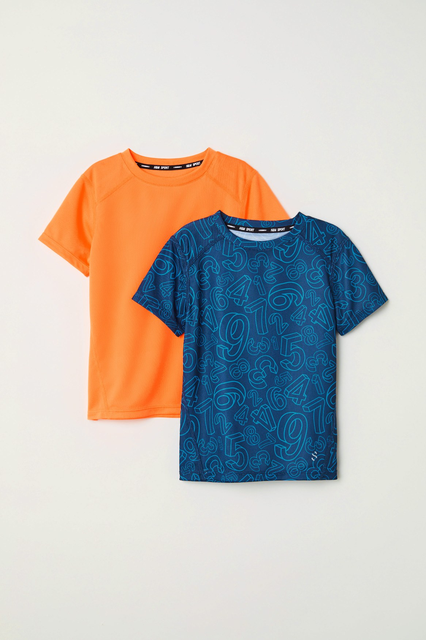

In [10]:
display_image(image1)

Image: fashion/0623784006.jpg


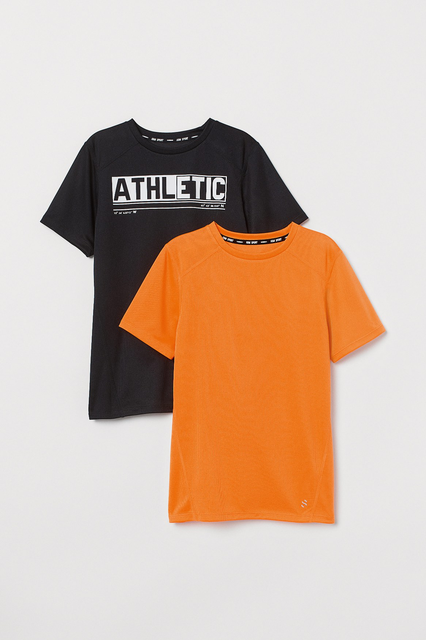

In [11]:
display_image(image2)

## 3D UMAP Projection of Image Embeddings

Same UMAP technique projected into 3D instead of 2D, providing an additional dimension to represent the neighborhood structure of the embeddings.

**Why 3D:**
1. Reduces information loss compared to 2D — more room to preserve distances
2. Can reveal cluster separations that appear overlapping in 2D
3. Interactive rotation (via Plotly) allows exploring the data from multiple angles

**Trade-off:** Harder to interpret at a glance than 2D, but can better capture complex relationships between image groups.

In [12]:
reducer_3d = umap.UMAP(n_components=3, metric="cosine")
embeddings_3d = reducer_3d.fit_transform(vectors)

In [24]:
fig_3d = px.scatter_3d(
    x=embeddings_3d[:, 0], y=embeddings_3d[:, 1], z=embeddings_3d[:, 2],
    hover_name=labels,
    title="3D UMAP Projection of Image Embeddings",
    width=1024, height=860,
)

fig_3d.update_traces(marker=dict(size=3, color="blue"))
fig_3d.show(renderer="iframe")

## Clustering with HDBSCAN

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups data points based on density — regions where points are packed closely together form clusters.

**Key advantages over KMeans:**
- No need to specify the number of clusters in advance — it discovers them automatically
- Detects clusters of varying shapes and sizes, not just spherical ones
- Identifies noise points (outliers) that don't belong to any cluster, labeled as `-1`

**How it works:**
1. Estimates the density around each point using mutual reachability distances
2. Builds a hierarchy of clusters by progressively removing lower-density connections
3. Extracts the most stable clusters from the hierarchy based on persistence

**Key parameter:** `min_cluster_size` controls the minimum number of points required to form a cluster. Lower values produce more (smaller) clusters, higher values produce fewer (larger) clusters.

**Why pair with UMAP:** UMAP preserves local density structure when projecting embeddings, making HDBSCAN particularly effective at finding meaningful clusters in the reduced space.

In [14]:
# HDBSCAN — automatically finds number of clusters
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean")
cluster_labels = clusterer.fit_predict(embeddings_3d)

print(f"🔢 Number of clusters = {len(set(cluster_labels)) - 1}")  # -1 excludes noise
print(f"🔇 Noise points = {(cluster_labels == -1).sum()}")

🔢 Number of clusters = 8
🔇 Noise points = 43


In [23]:
fig_3d = px.scatter_3d(
    x=embeddings_3d[:, 0], y=embeddings_3d[:, 1], z=embeddings_3d[:, 2],
    hover_name=labels,
    color=[str(c) for c in cluster_labels],
    title="3D UMAP Projection — Clustered",
    width=1024, height=860,
)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.show(renderer="iframe")

In [16]:
# Saving all images to a cluster in a dict
clusters = defaultdict(list)

for label, cluster_id in zip(labels, cluster_labels):
    clusters[cluster_id].append(label)

for cid, files in sorted(clusters.items()):
    print(f"Cluster {cid:02} = {len(files):04} images")

Cluster -1 = 0043 images
Cluster 00 = 0513 images
Cluster 01 = 0056 images
Cluster 02 = 0031 images
Cluster 03 = 0081 images
Cluster 04 = 0199 images
Cluster 05 = 0097 images
Cluster 06 = 0041 images
Cluster 07 = 0939 images


In HDBSCAN, cluster `-1` represents **noise** — points that the algorithm
could not confidently assign to any cluster.

These are typically:
- Images whose embeddings are isolated, not close enough to any dense region
- Outliers or visually unique items that don't share strong similarity with others
- Points in low-density areas between clusters

This is a feature, not a bug — HDBSCAN deliberately avoids forcing every point
into a cluster (unlike KMeans), which produces more meaningful groupings.

In [25]:
cluster_counts = {cid: len(files) for cid, files in sorted(clusters.items())}
sorted_counts = dict(sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True))

fig = px.bar(
    x=[str(c) for c in sorted_counts.keys()],
    y=list(sorted_counts.values()),
    title="Number of Images per Cluster (sorted)",
    labels={"x": "Cluster", "y": "Number of Images"},
    width=1024, height=640,
    color_discrete_sequence=["blue"],
)
fig.update_xaxes(type="category")  # preserve the sorted order
fig.update_traces(text=list(sorted_counts.values()), textposition="outside")
fig.show(renderer="iframe")

Image: fashion/0395864036.jpg


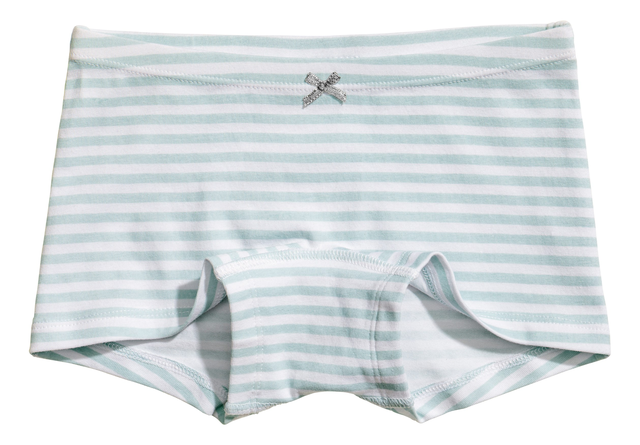

Image: fashion/0395864046.jpg


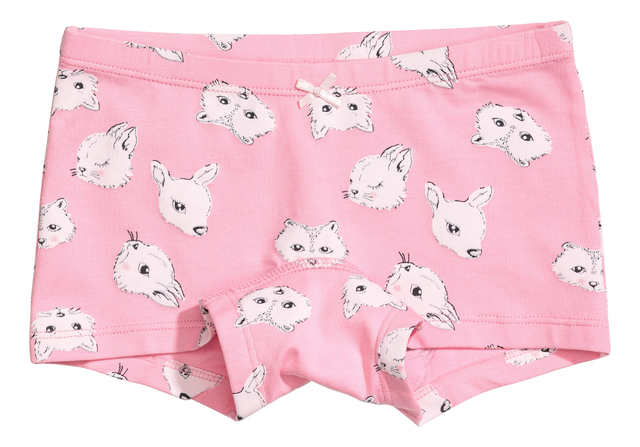

Image: fashion/0395864060.jpg


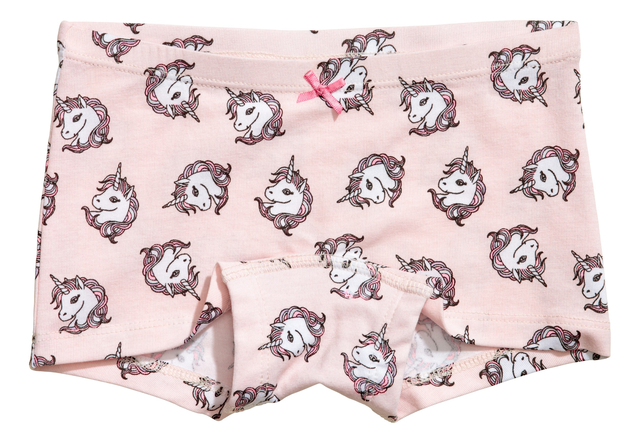

Image: fashion/0395864063.jpg


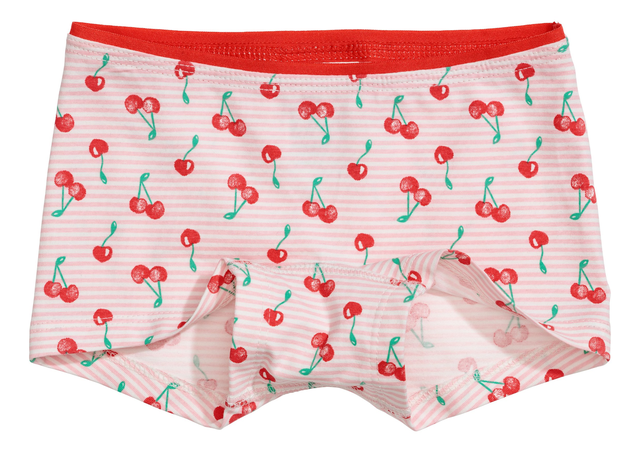

Image: fashion/0395864064.jpg


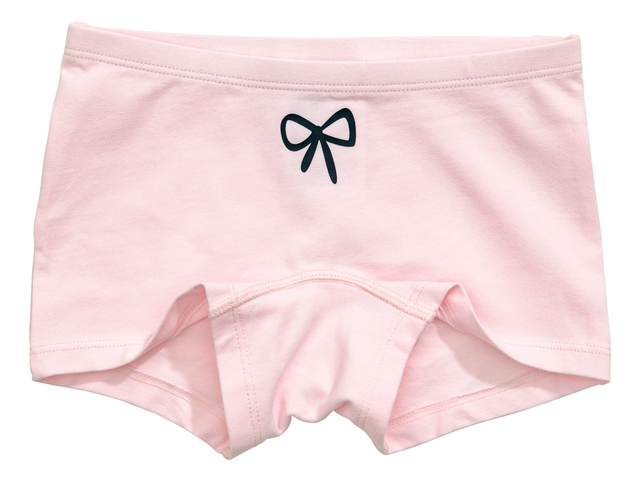

In [18]:
# Display all images from cluster 1
target_cluster = 1

for image_path in clusters[target_cluster][:5]:
    display_image(image_path)

Image: fashion/0391598044.jpg


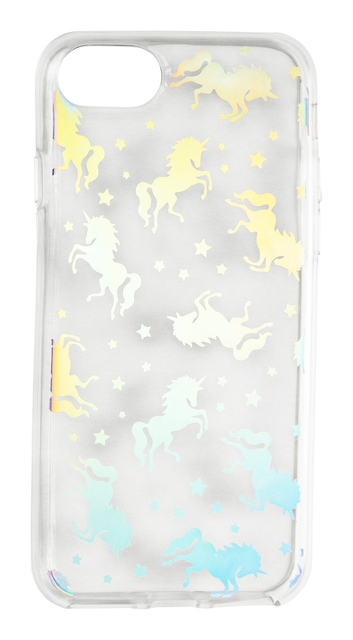

Image: fashion/0391598046.jpg


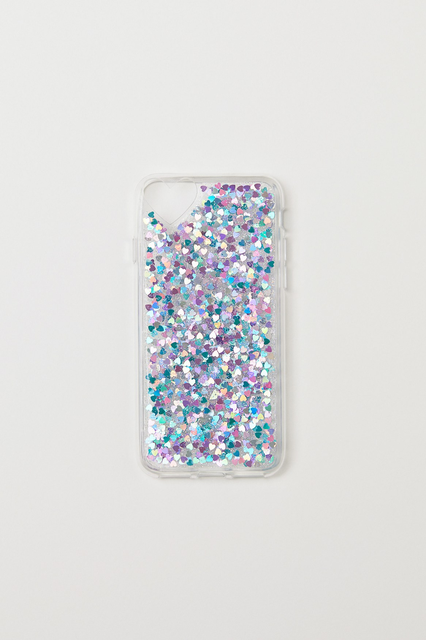

Image: fashion/0391598059.jpg


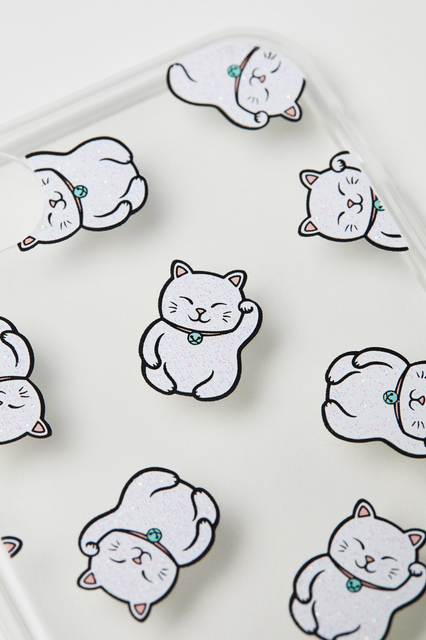

Image: fashion/0391598061.jpg


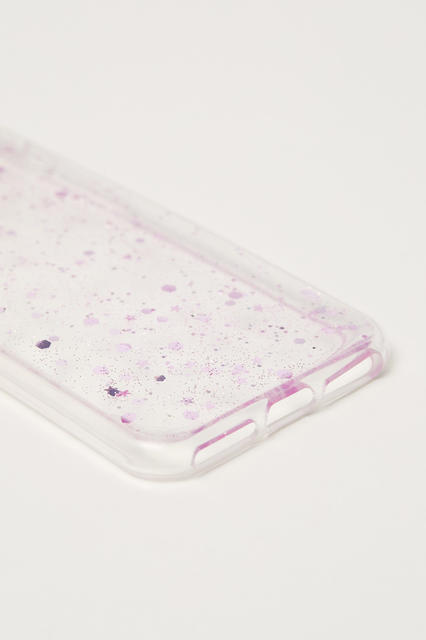

Image: fashion/0391598062.jpg


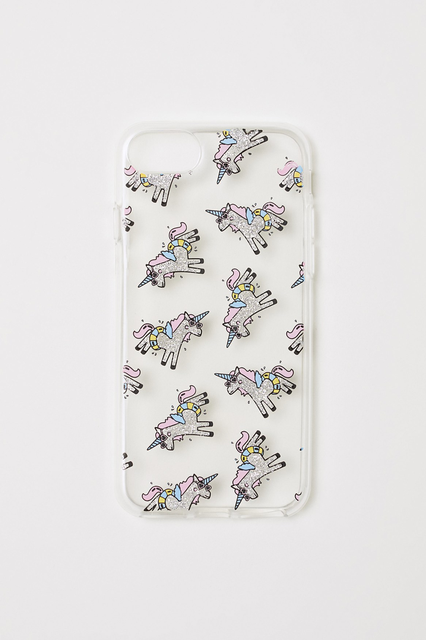

In [19]:
# Display all images from cluster 6
target_cluster = 6

for image_path in clusters[target_cluster][:5]:
    display_image(image_path)